# Finetuning

1) [Downloading of interesting tiles](#downloading-of-interesting-tiles)
2) [Preprocessing](#preprocessings) \
    2.1) [Masks](#masks) \
    2.2) [Probas](#probas)
3) [Prepare architecture for testing](#prepare-architecture-for-testing)
4) [Test with ipywidget](#tests-with-ipywidget)
5) [Test with napari](#tests-with-napari)
6) [Other stuff](#other-stuff)

List of parameters that can be tweaked:
- stride
- threshold_preds
- threshold_grouping
- resolutions
- dbscan_eps
- dbscan_min_samples
- min_cluster_size

In [1]:
# %matplotlib notebook
%matplotlib widget
%gui qt
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ipywidgets as widgets
from IPython.display import display
import rasterio
from PIL import Image
import plotly.express as px
import pyautogui as pag
from tqdm import tqdm
import geopandas as gpd
import datetime
import requests
import tifffile as tiff

Image.MAX_IMAGE_PIXELS = None

### Downloading of interesting tiles

In [2]:
def download_tile(E, N, dest, suffixe=''):
    year = datetime.date.today().year
    url_img = f"https://data.geo.admin.ch/ch.swisstopo.swissimage-dop10/swissimage-dop10_{year}_{E}-{N}/swissimage-dop10_{year}_{E}-{N}_0.1_2056.tif"
    count_down = 0
    while requests.get(url_img).status_code != 200:
        if count_down > 10:
            print(f"Could not find a tile for coordinates {E}-{N}")
            return
        year -= 1
        count_down += 1
        url_img = f"https://data.geo.admin.ch/ch.swisstopo.swissimage-dop10/swissimage-dop10_{year}_{E}-{N}/swissimage-dop10_{year}_{E}-{N}_0.1_2056.tif"

    img_data = requests.get(url_img).content
    if suffixe != '':
        file_src = os.path.join(dest, f"tile_{E}-{N}_{year}_{suffixe}.tif")
    else:
        file_src = os.path.join(dest, f"tile_{E}-{N}_{year}.tif")
    with open(file_src, 'wb') as handler:
        handler.write(img_data)
    return file_src


In [3]:
tiles_refs = {
    "big_landslides": r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\big_landslide\big_landslides.gpkg",
    "small_landslides": r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\small_landslide\small_landslides.gpkg",
    "rock_outcrop": r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\rock_outcrop\rock_outcrop.gpkg",
    "plateau": r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\plateau\plateau.gpkg"
}
tiles_refs = {
    0: r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\for_training\affleurements_rocheux\affleurements_rocheux.gpkg",
    1: r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\for_training\arbres_morts\dead_trees.gpkg",
    2: r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\for_training\champs_nuds\champs_nuds.gpkg",
    3: r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\for_training\neige\neige.gpkg"
}

for _, tiles_ref_src in tqdm(enumerate(tiles_refs.values()), total=len(tiles_refs)):
    tiles_refs = gpd.read_file(tiles_ref_src)
    folder_path = os.path.dirname(tiles_ref_src)
    ids = tiles_refs.id.values
    E = [x.split('_')[0] for x in ids]
    N = [x.split('_')[1] for x in ids]
    for x,y in zip(E,N):
        download_tile(x,y,folder_path)
    # print(EN)


  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [16:21<00:00, 245.41s/it]


### Preprocessings

#### masks

In [69]:
src_folder = r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\plateau\masks"
list_files = [x for x in os.listdir(src_folder) if 'transparent' not in x]
for _, mask_name in tqdm(enumerate(list_files), total=len(list_files)):
    src_mask = os.path.join(src_folder, mask_name)
    img_arr = np.array(Image.open(src_mask))
    img_arr_transparent = np.zeros((10000,10000,4), dtype=np.uint8)
    img_arr_transparent[...,:3] = img_arr
    mask = img_arr[:,:,0] == 255
    img_arr_transparent[:,:,3][mask] = 255
    # Image.fromarray(img_arr_transparent).save(os.path.splitext(src_mask)[0] + "_transparent.tif")
    Image.fromarray(img_arr_transparent).save(os.path.join(os.path.dirname(src_mask), os.path.basename(src_mask).replace('img', 'transparent')))

100%|██████████| 5/5 [00:06<00:00,  1.24s/it]


#### probas

In [2]:
floyd_colors = [[5.34629626e-01, 3.84273985e-01, 7.40962399e-01],
       [5.16587191e-01, 3.93223626e-01, 7.49201014e-01],
       [4.98036608e-01, 4.02202459e-01, 7.56882503e-01],
       [4.78392742e-01, 4.11037228e-01, 7.62028786e-01],
       [4.58141790e-01, 4.19837632e-01, 7.67200710e-01],
       [4.37482955e-01, 4.28920771e-01, 7.72509929e-01],
       [4.16003590e-01, 4.38070224e-01, 7.76614961e-01],
       [3.93187972e-01, 4.47015903e-01, 7.78989828e-01],
       [3.69465051e-01, 4.56137649e-01, 7.80463420e-01],
       [3.44764109e-01, 4.65605558e-01, 7.81838012e-01],
       [3.18987182e-01, 4.75319306e-01, 7.82122344e-01],
       [2.91213946e-01, 4.84928770e-01, 7.81287105e-01],
       [2.62047803e-01, 4.94622382e-01, 7.78604036e-01],
       [2.31110603e-01, 5.04822470e-01, 7.75776978e-01],
       [1.98277290e-01, 5.15503705e-01, 7.72811565e-01],
       [1.62403175e-01, 5.26287546e-01, 7.68702639e-01],
       [1.26260659e-01, 5.37466567e-01, 7.64024153e-01],
       [8.41007251e-02, 5.48782432e-01, 7.59188482e-01],
       [4.46730563e-02, 5.60280227e-01, 7.54098757e-01],
       [1.81510130e-02, 5.71406683e-01, 7.47867475e-01],
       [1.31449563e-02, 5.81846625e-01, 7.39836663e-01],
       [8.25997445e-03, 5.92229195e-01, 7.31830224e-01],
       [3.44712954e-03, 6.02536999e-01, 7.23762899e-01],
       [0.00000000e+00, 6.12636492e-01, 7.15242831e-01],
       [0.00000000e+00, 6.22102624e-01, 7.05086004e-01],
       [0.00000000e+00, 6.31547030e-01, 6.94962548e-01],
       [0.00000000e+00, 6.40979649e-01, 6.84873273e-01],
       [0.00000000e+00, 6.49780124e-01, 6.73265075e-01],
       [1.31274197e-04, 6.57605271e-01, 6.59492903e-01],
       [2.02784615e-04, 6.65064056e-01, 6.44937451e-01],
       [7.66443604e-04, 6.72487834e-01, 6.30272071e-01],
       [3.57048193e-03, 6.79892905e-01, 6.15516176e-01],
       [4.32684504e-02, 6.86402911e-01, 5.99110668e-01],
       [8.35080457e-02, 6.92823808e-01, 5.82589040e-01],
       [1.23523593e-01, 6.99158832e-01, 5.66225030e-01],
       [1.61235661e-01, 7.05337182e-01, 5.49864087e-01],
       [1.94455256e-01, 7.11367537e-01, 5.33160239e-01],
       [2.25063854e-01, 7.17269402e-01, 5.16138333e-01],
       [2.55408232e-01, 7.23116252e-01, 4.99280256e-01],
       [2.85437547e-01, 7.28944710e-01, 4.82723719e-01],
       [3.12360562e-01, 7.34846759e-01, 4.65631661e-01],
       [3.37300269e-01, 7.40901165e-01, 4.48275314e-01],
       [3.62375706e-01, 7.46966433e-01, 4.31001125e-01],
       [3.87179369e-01, 7.53016286e-01, 4.13493279e-01],
       [4.11138169e-01, 7.59291676e-01, 3.96075058e-01],
       [4.34505523e-01, 7.65796449e-01, 3.78835141e-01],
       [4.57546613e-01, 7.72318432e-01, 3.61118454e-01],
       [4.80812894e-01, 7.78880744e-01, 3.43502906e-01],
       [5.05131794e-01, 7.85041757e-01, 3.25436975e-01],
       [5.31217657e-01, 7.90294346e-01, 3.05968826e-01],
       [5.57290616e-01, 7.95490629e-01, 2.86568296e-01],
       [5.83282359e-01, 8.00655682e-01, 2.67335478e-01],
       [6.10817610e-01, 8.04442504e-01, 2.46314714e-01],
       [6.38710450e-01, 8.07383043e-01, 2.23213856e-01],
       [6.67140744e-01, 8.09299063e-01, 1.99628959e-01],
       [6.95076116e-01, 8.11173655e-01, 1.76068644e-01],
       [7.22831509e-01, 8.12398621e-01, 1.50497360e-01],
       [7.50794877e-01, 8.11199831e-01, 1.17137888e-01],
       [7.78232628e-01, 8.09331000e-01, 8.43906997e-02],
       [8.04989013e-01, 8.07435515e-01, 4.67942162e-02],
       [8.30765951e-01, 8.04940133e-01, 1.60080898e-02],
       [8.54778171e-01, 7.99544161e-01, 4.28941821e-03],
       [8.77120306e-01, 7.92669711e-01, 2.98252011e-03],
       [8.99191885e-01, 7.85847766e-01, 1.68799055e-03],
       [9.21059333e-01, 7.79111790e-01, 4.08011382e-04],
       [9.37528493e-01, 7.68599901e-01, 6.89072103e-07],
       [9.51509021e-01, 7.56314258e-01, 8.36489975e-07],
       [9.65568650e-01, 7.44039357e-01, 1.92536345e-06],
       [9.78936841e-01, 7.31461871e-01, 7.65870830e-07],
       [9.87960637e-01, 7.17501060e-01, 8.82950168e-07],
       [9.91348506e-01, 7.02589274e-01, 1.07971534e-06],
       [9.94721894e-01, 6.87582838e-01, 7.26348189e-07],
       [9.97741884e-01, 6.72460297e-01, 1.23595340e-06],
       [1.00000000e+00, 6.57228901e-01, 4.29474948e-07],
       [1.00000000e+00, 6.41952374e-01, 5.30975176e-07],
       [1.00000000e+00, 6.26564729e-01, 8.81498133e-07],
       [1.00000000e+00, 6.11057236e-01, 6.20692557e-07],
       [1.00000000e+00, 5.95579903e-01, 7.11884351e-03],
       [1.00000000e+00, 5.80073530e-01, 1.86656885e-02],
       [1.00000000e+00, 5.64502678e-01, 3.34843450e-02],
       [1.00000000e+00, 5.48804869e-01, 4.89718529e-02],
       [1.00000000e+00, 5.33007106e-01, 6.37685246e-02],
       [1.00000000e+00, 5.17184242e-01, 7.96445395e-02],
       [1.00000000e+00, 5.01231267e-01, 9.44611304e-02],
       [1.00000000e+00, 4.85258224e-01, 1.10112102e-01],
       [1.00000000e+00, 4.68988682e-01, 1.23559514e-01],
       [1.00000000e+00, 4.52160038e-01, 1.33169663e-01],
       [1.00000000e+00, 4.34713586e-01, 1.39864808e-01],
       [1.00000000e+00, 4.16897149e-01, 1.46785206e-01],
       [1.00000000e+00, 3.98627115e-01, 1.53660088e-01],
       [9.98413472e-01, 3.80599629e-01, 1.63072149e-01],
       [9.96367869e-01, 3.62446388e-01, 1.73551327e-01],
       [9.94226668e-01, 3.43819782e-01, 1.83828721e-01],
       [9.90540096e-01, 3.25754732e-01, 1.95568620e-01],
       [9.84627470e-01, 3.08696537e-01, 2.08284845e-01],
       [9.75150534e-01, 2.94967236e-01, 2.22838271e-01],
       [9.65661878e-01, 2.81553625e-01, 2.37633818e-01],
       [9.56207836e-01, 2.68295705e-01, 2.52246077e-01],
       [9.46973791e-01, 2.58028598e-01, 2.71052395e-01],
       [9.37988724e-01, 2.50815713e-01, 2.93111378e-01]]

floyd_size = len(floyd_colors)
floyd_colors_half_bot = floyd_colors[:floyd_size//2]
floyd_colors_half_top = floyd_colors[floyd_size//2::]
print(len(floyd_colors_half_top))
print(len(floyd_colors_half_bot))

50
50


In [3]:
cmapRB = cm.get_cmap("RdYlBu")
colors_RB = [cmapRB(i) for i in np.linspace(0, 1, 100)]
print(colors_RB)

[(np.float64(0.6470588235294118), np.float64(0.0), np.float64(0.14901960784313725), np.float64(1.0)), (np.float64(0.6624375240292195), np.float64(0.014763552479815456), np.float64(0.1493271818531334), np.float64(1.0)), (np.float64(0.6855055747789311), np.float64(0.03690888119953864), np.float64(0.14978854286812765), np.float64(1.0)), (np.float64(0.700884275278739), np.float64(0.0516724336793541), np.float64(0.1500961168781238), np.float64(1.0)), (np.float64(0.7239523260284506), np.float64(0.07381776239907728), np.float64(0.15055747789311805), np.float64(1.0)), (np.float64(0.7393310265282584), np.float64(0.08858131487889273), np.float64(0.1508650519031142), np.float64(1.0)), (np.float64(0.7623990772779701), np.float64(0.11072664359861592), np.float64(0.15132641291810842), np.float64(1.0)), (np.float64(0.7854671280276817), np.float64(0.1328719723183391), np.float64(0.15178777393310267), np.float64(1.0)), (np.float64(0.8008458285274894), np.float64(0.14763552479815456), np.float64(0.15209

C:\Users\swann\AppData\Local\Temp\ipykernel_30452\4234603430.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmapRB = cm.get_cmap("RdYlBu")


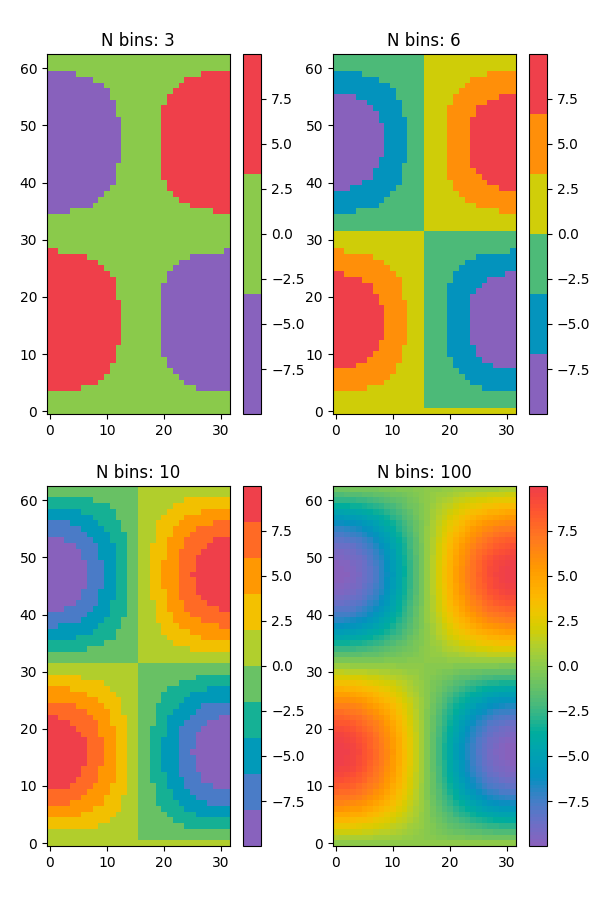

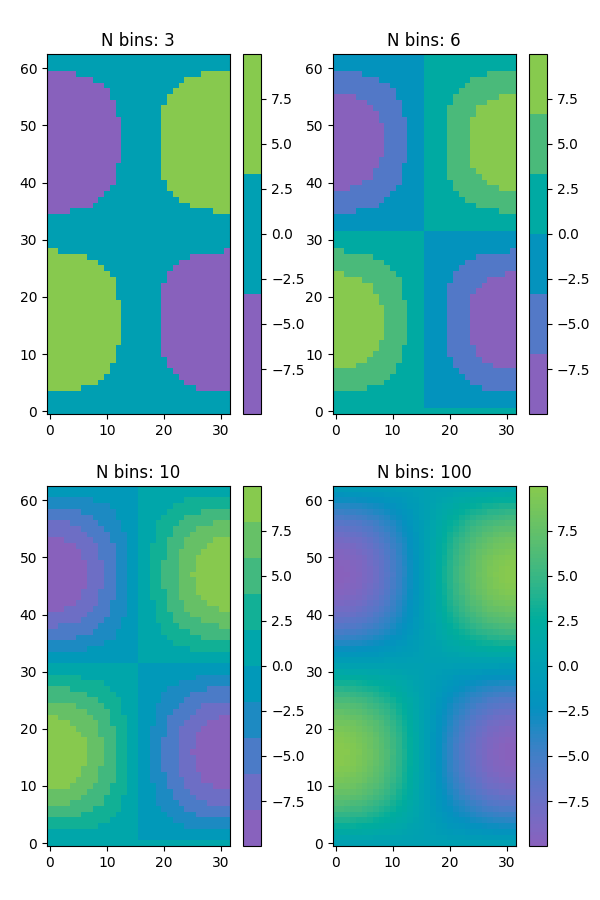

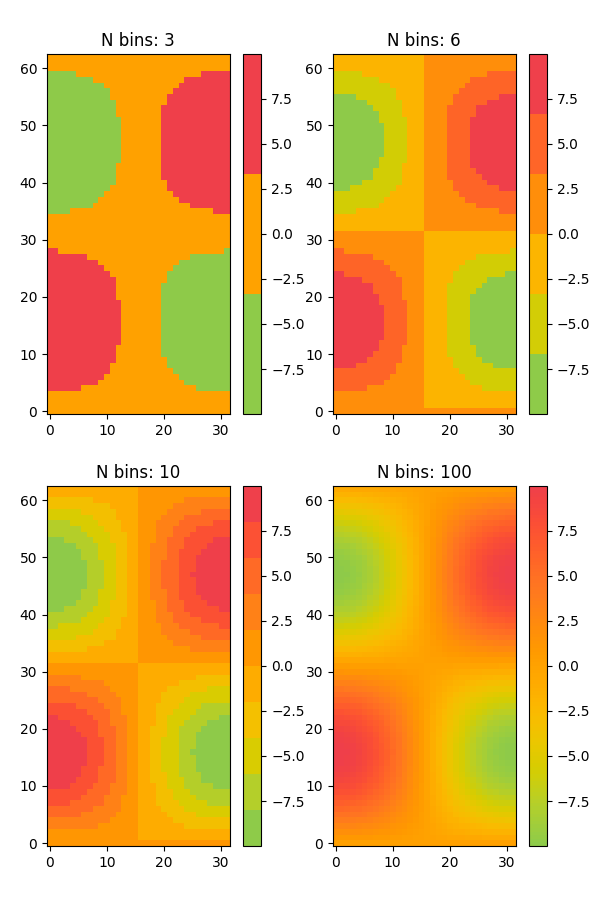

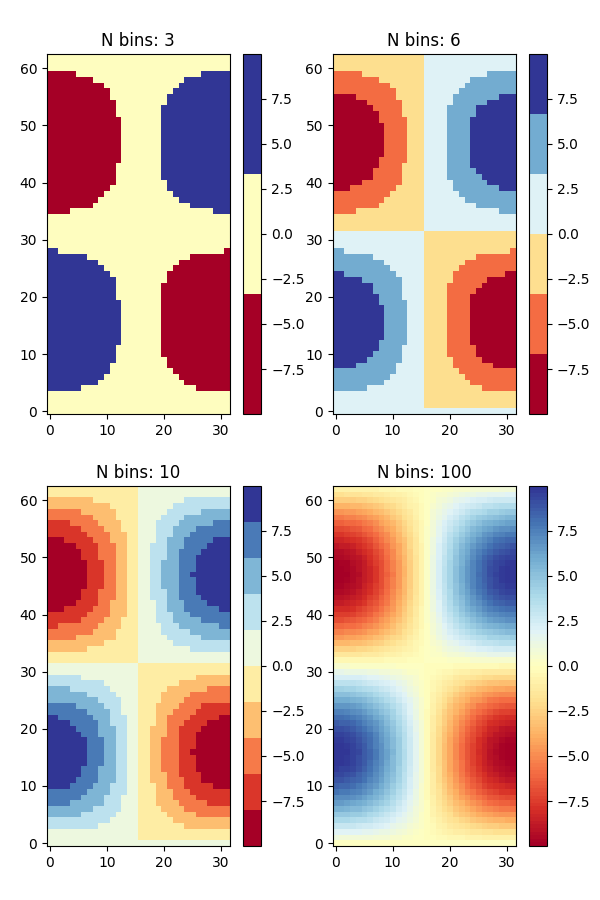

In [4]:
from matplotlib.colors import LinearSegmentedColormap


for colors in [floyd_colors, floyd_colors_half_bot, floyd_colors_half_top, colors_RB]:
    x = np.arange(0, np.pi, 0.1)
    y = np.arange(0, 2 * np.pi, 0.1)
    X, Y = np.meshgrid(x, y)
    Z = np.cos(X) * np.sin(Y) * 10
    # colors = [(1, 0, 0), (0, 1, 0), (0, 0, 1)]  # R -> G -> B
    # colors = floyd_colors_half_bot
    n_bins = [3, 6, 10, 100]  # Discretizes the interpolation into bins
    cmap_name = 'my_list'
    fig, axs = plt.subplots(2, 2, figsize=(6, 9))
    fig.subplots_adjust(left=0.02, bottom=0.06, right=0.95, top=0.94, wspace=0.05)
    for n_bin, ax in zip(n_bins, axs.flat):
        # Create the colormap
        cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bin)
        # Fewer bins will result in "coarser" colomap interpolation
        im = ax.imshow(Z, origin='lower', cmap=cmap)
        ax.set_title("N bins: %s" % n_bin)
        fig.colorbar(im, ax=ax)

In [ ]:
def prob_to_rgb(prob_map, cmap_name="RdYlBu"):
    """
    prob_map: (H, W) float32 in [0, 1]
    returns: (H, W, 3) uint8
    """
    # cmap = cm.get_cmap(cmap_name)
    cmapRB = cm.get_cmap("RdYlBu")
    colors_RB = [cmapRB(i) for i in np.linspace(0, 1, 100)]
    cmap = LinearSegmentedColormap.from_list(cmap_name, colors_RB, N=10).reversed()
    # Apply colormap → RGBA in [0,1]
    rgba = cmap(prob_map)

    # Drop alpha channel and convert to uint8
    rgb = (rgba[..., :3] * 255).astype(np.uint8)

    return rgb

src_folder = r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\plateau\probas"
list_files = [x for x in os.listdir(src_folder) if 'transparent' not in x]
for _, proba_name in tqdm(enumerate(list_files), total=len(list_files)):
    src = os.path.join(src_folder, proba_name)
    img_arr = np.array(Image.open(src))
    img_rgb = prob_to_rgb(img_arr)
    img_rgb_transparent = np.zeros((img_arr.shape[0], img_arr.shape[1], 4), dtype=np.uint8)
    img_rgb_transparent[..., :3] = img_rgb
    img_rgb_transparent[..., 3][img_arr >= 0.05] = 255
    # Image.fromarray(img_rgb_transparent).save(os.path.splitext(src)[0] + "_transparent.tif")
    Image.fromarray(img_rgb_transparent).save(os.path.join(os.path.dirname(src), os.path.basename(src).replace('mask', 'transparent')))

100%|██████████| 5/5 [00:22<00:00,  4.55s/it]


### Prepare architecture for testing

In [19]:
from itertools import product
from PIL import Image, ImageDraw, ImageFont

In [33]:
def create_img(dest, width, height, text, text_height=0, text_size=10, background=(255, 255, 255, 255)):
    img = Image.new("RGBA", (width, height), background)
    draw = ImageDraw.Draw(img)


    # Load a font (fallback if not found)
    try:
        font = ImageFont.truetype("arial.ttf", size=text_size)
    except IOError:
        font = ImageFont.load_default()

    # Compute text size and center position
    bbox = draw.textbbox((0, 0), text, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    x = (width - text_w) // 2
    y = (height - text_h) // 2 + text_height

    # Draw text
    draw.text((x, y), text, fill=(0,0,0), font=font)

    # Save
    img.save(dest)

In [39]:


src_root = r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions"
src_preds = os.path.join(src_root, 'preds')
src_originals = os.path.join(src_root, 'originals')
os.makedirs(src_preds, exist_ok=True)
os.makedirs(src_originals, exist_ok=True)
lst_stride = [128, 256, 512]
lst_minsize = [100, 1000, 5000]
lst_th_pred = [0.05, 0.1, 0.3, 0.5, 0.7]
lst_th_group = [0.05, 0.1, 0.3, 0.5, 0.7]
A = np.array([1,2,3])
B = np.array([4, 5])

# create original images
for img_number in range(4):
    src_img = os.path.join(src_originals, f'image_{img_number}.tif')
    create_img(src_img, 256, 256, f"Image {img_number}",text_size=14)

# loop on any combinations possible
for _, (stride, minsize, th_pred, th_group) in tqdm(enumerate(product(lst_stride, lst_minsize, lst_th_pred, lst_th_group)), total=len(list(product(lst_stride, lst_minsize, lst_th_pred, lst_th_group)))):
    # prepare architecture
    str_folder_name = os.path.join(src_preds, f"stride={stride}_minsize={minsize}_thpred={th_pred}_thgroup={th_group}")
    os.makedirs(str_folder_name, exist_ok=True)
    os.makedirs(os.path.join(str_folder_name, 'masks'), exist_ok=True)
    os.makedirs(os.path.join(str_folder_name, 'probas'), exist_ok=True)
    os.makedirs(os.path.join(str_folder_name, 'inter'), exist_ok=True)

    # create images for mask and probas
    for img_number in range(4):
        src_mask = os.path.join(str_folder_name, 'masks', f'image_{img_number}.tif')
        src_proba = os.path.join(str_folder_name, 'probas', f'image_{img_number}.tif')
        label_mask = f"mask {img_number} - stride={stride}_minsize={minsize}_thpred={th_pred}_thgroup={th_group}"
        label_proba = f"proba {img_number} - stride={stride}_minsize={minsize}_thpred={th_pred}_thgroup={th_group}"
        create_img(src_mask, 256, 256, label_mask, -30, 9, (0,0,0,0))
        create_img(src_proba, 256, 256, label_proba, 30, 9, (0,0,0,0))


100%|██████████| 225/225 [00:21<00:00, 10.28it/s]


### Tests with ipywidget

In [ ]:
class finetuning_window():
    def __init__(self, src_dest):
        self.src_dest = src_dest
        self.ax = None
        self.original_image = None
        self.original_mask = None
        self.original_proba = None

        src_originals = os.path.join(src_dest, 'originals')
        src_masks = os.path.join(src_dest, 'masks')
        src_probas = os.path.join(src_dest, 'probas')
        # src_vectors = os.path.join(src_dest, 'vectors')
        
        self.dict_images = {
            os.path.join(src_originals, x):{
                # 'vector': os.path.join(self.src_vectors, x),
                'mask': os.path.join(src_masks, os.path.splitext(x)[0] + "_transparent.tif"),
                'proba':os.path.join(src_probas, os.path.splitext(x)[0] + "_transparent.tif"),
            }
            for x in os.listdir(src_originals) }
        
        self.src_original = list(self.dict_images)[0]
        self.src_mask = None
        self.src_proba = None

        # Create interface:
        self.wid_image_out = widgets.Output()

        # sample selection
        self.wid_dropdown_img = widgets.Dropdown(
            # options=["Affleurement rocheux", "Petite glissement", "Gros glissement", "Plateau"],
            options=[os.path.basename(x) for x in list(self.dict_images)],
            description="Image : "
        )

        # layers to show
        self.wid_right_checkboxes = [
            # widgets.Checkbox(description=f"Polygons"),
            widgets.Checkbox(description=f"Mask"),
            widgets.Checkbox(description=f"Probas"),
        ]

        # th to proba invisible
        self.wid_slider_proba_inv_th = widgets.FloatSlider(
            description="Probas inv : ",
            min=0, max=1, step=0.01,
            continuous_update=False,
        )

        # stride and minsize
        self.wid_dropdown_stride = widgets.Dropdown(
            options=["128", "256", "512"],
            description="Stride : ",
        )
        self.wid_dropdown_minsize = widgets.Dropdown(
            options=["100", "1000", "5000"],
            description="Min Size : "
        )

        self.wid_dropdown_row = widgets.HBox([self.wid_dropdown_stride, self.wid_dropdown_minsize])

        # thresholds
        self.wid_slider_th_pred = widgets.SelectionSlider(
            options=[0.05, 0.1, 0.3, 0.5, 0.7],
            value=0.5,
            description="th pred : "

        )
        self.wid_slider_th_group = widgets.SelectionSlider(
            options=[0.05, 0.1, 0.3, 0.5, 0.7],
            value=0.5,
            description="th group : "

        )

        self.wid_slider_th_row = widgets.HBox([self.wid_slider_th_pred, self.wid_slider_th_group])

        # checkboxes
        resolutions = [1.0, 0.75, 0.5, 0.25, 0.1, 0.05]
        self.wid_checkboxes_res = [
            widgets.Checkbox(
                description=str(res),
                indent=False,
                layout=widgets.Layout(margin="0px"),
                value=True
            )
            for res in resolutions
        ]
        for cb in self.wid_checkboxes_res:
            cb.layout.width = "80px"

        self.wid_checkbox_grid = widgets.GridBox(
            self.wid_checkboxes_res,
            layout=widgets.Layout(
                grid_template_columns="repeat(3, min-content)",
                grid_gap="2px"
            )
        )

        self.wid_right_panel = widgets.VBox([
            self.vspace(100),
            widgets.Label(value="Sample:"),
            self.wid_dropdown_img,
            self.vspace(10),
            *self.wid_right_checkboxes,
            self.vspace(10),
            self.wid_slider_proba_inv_th,
            self.vspace(50),
            widgets.Label(value="Hyperparameters:"),
            self.vspace(10),
            self.wid_dropdown_row,
            self.vspace(10),
            self.hspace(self.wid_slider_th_row,12),
            self.vspace(10),
            # widgets.Label(value="Resolutions:"),
            # hspace(checkbox_grid, 50)
        ])

        # drawbacks connections
        self.wid_dropdown_img.observe(self.on_dropdown_change)

        for cb in self.wid_right_checkboxes:
            cb.observe(self.on_any_checkbox_change, names="value")

        # Display window
        self.wid_full_ui = widgets.HBox([
            self.wid_image_out,
            self.wid_right_panel
        ])

        with self.wid_image_out:
            self.show_image(list(self.dict_images)[0], self.dict_images[list(self.dict_images)[0]]['mask'], self.dict_images[list(self.dict_images)[0]]['proba'])
            
        display(self.wid_full_ui)

    
    @staticmethod    
    def vspace(px=15):
        return widgets.Box(layout=widgets.Layout(height=f"{px}px"))

    @staticmethod
    def hspace(obj, px=30):
        return widgets.HBox([
            widgets.Box(layout=widgets.Layout(width=f"{px}px")),
            obj,
        ])

    def show_image(self, src_original=None, src_mask=None, src_proba=None):
        if self.ax is None:
            plt.close("all")

            self.fig, self.ax = plt.subplots(figsize=(10, 10))

            with Image.open(src_original) as im:
                self.original_image = self.ax.imshow(np.array(im))

            with Image.open(src_proba) as im:
                self.proba_image = self.ax.imshow(np.array(im), alpha=0.6)

            with Image.open(src_mask) as im:
                self.mask_image = self.ax.imshow(np.array(im), alpha=0.6)

            self.src_original = src_original
            self.src_mask = src_mask
            self.src_proba = src_proba

            self.ax.set_xlim(0, 10000)
            self.ax.set_ylim(10000, 0)
            self.ax.set_xticks(np.arange(0, 10001, 1000))
            self.ax.set_yticks(np.arange(0, 10001, 1000))
            self.ax.grid(True)

            self.mask_image.set_visible(self.wid_right_checkboxes[0].value)
            self.proba_image.set_visible(self.wid_right_checkboxes[1].value)

            self.fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
            plt.show()
        else:
            if src_original is not None and src_original != self.src_original:
                with Image.open(src_original) as im:
                    self.original_image.set_data(np.array(im))
                self.src_original = src_original

            if src_proba is not None and src_proba != self.src_proba:
                with Image.open(src_proba) as im:
                    self.proba_image.set_data(np.array(im))
                self.src_proba = src_proba

            if src_mask is not None and src_mask != self.src_mask:
                with Image.open(src_mask) as im:
                    self.mask_image.set_data(np.array(im))
                self.src_mask = src_mask

            self.fig.canvas.draw_idle()

    def on_dropdown_change(self, change):
        if change["name"] == "value":
            src_original = os.path.join(self.src_dest, 'originals', change["new"])
            src_mask = self.dict_images[src_original]['mask']
            src_proba = self.dict_images[src_original]['proba']

            self.show_image(src_original, src_mask, src_proba)

    def on_any_checkbox_change(self, change):
        cb = change["owner"]
        new = change['new']

        if cb.description == "Probas":
            self.proba_image.set_visible(new)
        elif cb.description == "Mask":
            self.mask_image.set_visible(new)

In [3]:
src = r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning"
interactive_win = finetuning_window(src)

### Tests with Napari

#### stable version

In [3]:
import os
import numpy as np
from PIL import Image

import napari
from magicgui import magicgui

import geopandas as gpd
import rasterio
from shapely.geometry import Polygon, MultiPolygon


class NapariViewer:
    def __init__(self, src_dest):
        self.src_dest = src_dest
        print(src_dest)

        # Paths
        self.src_originals = os.path.join(src_dest, "originals")
        self.src_masks = os.path.join(src_dest, "masks")
        self.src_probas = os.path.join(src_dest, "probas")
        self.src_vectors = os.path.join(src_dest, "vectors")

        # Build image dictionary
        self.dict_images = {
            x: {
                "original": os.path.join(self.src_originals, x),
                "mask": os.path.join(
                    self.src_masks, os.path.splitext(x)[0] + "_transparent.tif"
                ),
                "proba": os.path.join(
                    self.src_probas, os.path.splitext(x)[0] + "_transparent.tif"
                ),
                "vector": os.path.join(
                    self.src_vectors, os.path.splitext(x)[0] + ".gpkg"
                ),
            }
            for x in os.listdir(self.src_originals)
            if x.lower().endswith((".tif", ".tiff", ".png", ".jpg"))
        }

        if not self.dict_images:
            raise RuntimeError("No images found")

        # Create napari viewer
        self.viewer = napari.Viewer(title=os.path.basename(src_dest))

        # Load first image
        first_name = list(self.dict_images.keys())[0]
        self._load_layers(first_name)

        # Create control panel
        self._create_controls()

    # --------------------------------------------------
    # Internal helpers
    # --------------------------------------------------
    def _read_image(self, path):
        with Image.open(path) as im:
            return np.asarray(im)

    def _load_layers(self, image_name):
        paths = self.dict_images[image_name]

        # Read raster + transform
        with rasterio.open(paths["original"]) as src:
            original = src.read().transpose(1, 2, 0)
            self.transform = src.transform

        # Load data
        original = self._read_image(paths["original"])
        mask = self._read_image(paths["mask"])
        proba = self._read_image(paths["proba"])

        polygons = self._load_vectors(paths["vector"])

        # If layers already exist → update data
        if hasattr(self, "layer_original"):
            self.layer_original.data = original
            self.layer_mask.data = mask
            self.layer_proba.data = proba
            self.layer_vectors.data = polygons
            return

        # Otherwise create layers once
        self.layer_original = self.viewer.add_image(
            original,
            name="Original",
            rgb=True,
            interpolation="nearest",
        )

        self.layer_proba = self.viewer.add_image(
            proba,
            name="Probas",
            opacity=0.6,
            visible=True,
            interpolation="nearest",
        )

        self.layer_mask = self.viewer.add_image(
            mask,
            name="Mask",
            opacity=1.0,
            visible=False,
            interpolation="nearest",
        )

        self.layer_vectors = self.viewer.add_shapes(
            polygons,
            shape_type="polygon",
            name="Vectors",
            edge_color="yellow",
            face_color="transparent",
            edge_width=5,
            visible=True,
            opacity=1.0,
        )
    
    def _load_vectors(self, vector_path):
        if not os.path.exists(vector_path):
            return []

        gdf = gpd.read_file(vector_path)
        polygons = []

        for geom in gdf.geometry:
            if geom is None:
                continue

            if isinstance(geom, Polygon):
                geoms = [geom]
            elif isinstance(geom, MultiPolygon):
                geoms = geom.geoms
            else:
                continue

            for poly in geoms:
                coords = np.array(poly.exterior.coords)
                rc = [~self.transform * (x, y) for x, y in coords]
                polygons.append(np.array(rc)[:, ::-1])  # (row, col)

        return polygons
    
    # --------------------------------------------------
    # UI (magicgui)
    # --------------------------------------------------
    def _create_controls(self):
        @magicgui(
            image_name={
                "choices": list(self.dict_images.keys())
            },
            stride={
                "choices": [128, 256, 512],
                "value": 256,
            },
            minsize={
                "choices": [100, 1000, 5000, 10000],
                "value": 1000,
            },
            thpred={
                "choices": [0.05, 0.1, 0.3, 0.5],
                "value": 0.5,
            },
            thgroup={
                "choices": [0.05, 0.1, 0.3, 0.5],
                "value": 0.5,
            },
            proba_opacity={"min": 0, "max": 1, "step": 0.05},

            layout="vertical",
            auto_call=True,
        )
        def controls(
            image_name: str,
            stride: int,
            minsize: int,
            thpred: float,
            thgroup: float,
            show_mask: bool = False,
            show_probas: bool = True,
            show_vectors: bool = True,
            mask_opacity: float = 1.0,
            proba_opacity: float = 0.6,
        ):
            # Switch image
            self._load_layers(image_name)

            # Toggle visibility
            self.layer_mask.visible = show_mask
            self.layer_proba.visible = show_probas
            self.layer_vectors.visible = show_vectors

            # Update opacity
            self.layer_mask.opacity = mask_opacity
            self.layer_proba.opacity = proba_opacity

        # Dock widget in napari
        self.viewer.window.add_dock_widget(
            controls, area="right", name="Finetuning controls"
        )


In [10]:
src_dest = r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\big_landslide"

viewer = NapariViewer(src_dest)
napari.run()

D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\interesting_tiles\big_landslide


C:\Users\swann\AppData\Local\Temp\ipykernel_16940\1211712938.py:86: FutureWarning: Argument 'interpolation' is deprecated, please use 'interpolation2d' instead. The argument 'interpolation' was deprecated in 0.4.17 and it will be removed in 0.6.0.
  self.layer_original = self.viewer.add_image(
C:\Users\swann\AppData\Local\Temp\ipykernel_16940\1211712938.py:93: FutureWarning: Argument 'interpolation' is deprecated, please use 'interpolation2d' instead. The argument 'interpolation' was deprecated in 0.4.17 and it will be removed in 0.6.0.
  self.layer_proba = self.viewer.add_image(
C:\Users\swann\AppData\Local\Temp\ipykernel_16940\1211712938.py:101: FutureWarning: Argument 'interpolation' is deprecated, please use 'interpolation2d' instead. The argument 'interpolation' was deprecated in 0.4.17 and it will be removed in 0.6.0.
  self.layer_mask = self.viewer.add_image(


d:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\.venv\lib\site-packages\rasterio\__init__.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
d:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\.venv\lib\site-packages\rasterio\__init__.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
d:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\.venv\lib\site-packages\rasterio\__init__.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
d:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\.venv\lib\site-packages\rasterio\__init__.py:387: NotGe

#### le chantier

In [16]:
import os
import numpy as np
from PIL import Image

import napari
from magicgui import magicgui

import geopandas as gpd
import rasterio
from shapely.geometry import Polygon, MultiPolygon


class FinetuningNapari:
    def __init__(self, src_dest):
        self.src_dest = src_dest
        print(src_dest)

        # Paths
        self.src_originals = os.path.join(src_dest, "originals")
        self.src_masks = os.path.join(src_dest, "masks")
        self.src_probas = os.path.join(src_dest, "probas")
        self.src_vectors = os.path.join(src_dest, "vectors")
        self.config = {
            "stride": 256,
            "minsize": 1000,
            "thpred": 0.5,
            "thgroup": 0.5
        }

        # Build image dictionary
        self.list_images = [x for x in os.listdir(os.path.join(self.src_dest, 'originals')) if x.lower().endswith((".tif", ".tiff", ".png", ".jpg"))]

        if len(self.list_images) == 0:
            raise RuntimeError("No images found")

        # Create napari viewer
        self.viewer = napari.Viewer(title=os.path.basename(src_dest))

        # Load first image
        self._load_layers(self.list_images[0])

        # Create control panel
        self._create_controls()

    # --------------------------------------------------
    # Internal helpers
    # --------------------------------------------------
    def _read_image(self, path):
        with rasterio.open(path) as src:
            print(path)
            print(src.read().shape)
            print('---')
            return np.moveaxis(src.read(), 0, 2)
        # with Image.open(path) as im:
        #     return np.asarray(im)

    def _load_layers(self, image_name):
        # paths = self.dict_images[image_name]
        current_config = f"stride={self.config['stride']}_minsize={self.config['minsize']}_thpred={self.config['thpred']}_thgroup={self.config['thgroup']}"
        mask_transparent = os.path.splitext(image_name)[0] + "_transparent.tif"
        proba_transparent = os.path.splitext(image_name)[0] + "_probas_transparent.tif"
        vector_layer = os.path.splitext(image_name)[0] + "_maskclusters_eps_3_min_samp_20_mask_landslides.gpkg"
        paths = {
            'original': os.path.join(self.src_dest, "originals", image_name),
            'mask': os.path.join(self.src_dest, "preds", current_config, 'masks', mask_transparent),
            'proba': os.path.join(self.src_dest, "preds", current_config, 'probas', proba_transparent),
            'vector': os.path.join(self.src_dest, "preds", current_config, 'vectors', image_name),
        }

        # Read raster + transform
        with rasterio.open(paths["original"]) as src:
            original = src.read().transpose(1, 2, 0)
            self.transform = src.transform

        # Load data
        original = self._read_image(paths["original"])
        mask = self._read_image(paths["mask"])
        proba = self._read_image(paths["proba"])

        # polygons = self._load_vectors(paths["vector"])

        # If layers already exist → update data
        if hasattr(self, "layer_original"):
            self.layer_original.data = original
            self.layer_mask.data = mask
            self.layer_proba.data = proba
            # self.layer_vectors.data = polygons
            return

        # Otherwise create layers once
        self.layer_original = self.viewer.add_image(
            original,
            name="Original",
            rgb=True,
            interpolation="nearest",
        )

        self.layer_proba = self.viewer.add_image(
            proba,
            name="Probas",
            opacity=0.6,
            visible=True,
            interpolation="nearest",
        )

        self.layer_mask = self.viewer.add_image(
            mask,
            name="Mask",
            opacity=1.0,
            visible=False,
            interpolation="nearest",
        )

        # self.layer_vectors = self.viewer.add_shapes(
        #     polygons,
        #     shape_type="polygon",
        #     name="Vectors",
        #     edge_color="yellow",
        #     face_color="transparent",
        #     edge_width=5,
        #     visible=True,
        #     opacity=1.0,
        # )
    
    def _load_vectors(self, vector_path):
        if not os.path.exists(vector_path):
            return []

        gdf = gpd.read_file(vector_path)
        polygons = []

        for geom in gdf.geometry:
            if geom is None:
                continue

            if isinstance(geom, Polygon):
                geoms = [geom]
            elif isinstance(geom, MultiPolygon):
                geoms = geom.geoms
            else:
                continue

            for poly in geoms:
                coords = np.array(poly.exterior.coords)
                rc = [~self.transform * (x, y) for x, y in coords]
                polygons.append(np.array(rc)[:, ::-1])  # (row, col)

        return polygons
    
    # --------------------------------------------------
    # UI (magicgui)
    # --------------------------------------------------
    def _create_controls(self):
        @magicgui(
            image_name={
                "choices": list(self.list_images)
            },
            stride={
                "choices": [128, 256, 512],
                "value": 256,
            },
            minsize={
                "choices": [100, 1000, 5000],
                "value": 1000,
            },
            thpred={
                "choices": [0.05, 0.1, 0.3, 0.5, 0.7],
                "value": 0.5,
            },
            thgroup={
                "choices": [0.05, 0.1, 0.3, 0.5, 0.7],
                "value": 0.5,
            },
            proba_opacity={"min": 0, "max": 1, "step": 0.05},

            layout="vertical",
            auto_call=True,
        )
        def controls(
            image_name: str,
            stride: int,
            minsize: int,
            thpred: float,
            thgroup: float,
            show_mask: bool = False,
            show_probas: bool = True,
            show_vectors: bool = True,
            mask_opacity: float = 1.0,
            proba_opacity: float = 0.6,
        ):
            
            # Update current config
            self.config['stride'] = stride
            self.config['minsize'] = minsize
            self.config['thpred'] = thpred
            self.config['thgroup'] = thgroup

            # Switch image
            self._load_layers(image_name)

            # Toggle visibility
            self.layer_mask.visible = show_mask
            self.layer_proba.visible = show_probas
            # self.layer_vectors.visible = show_vectors

            # Update opacity
            self.layer_mask.opacity = mask_opacity
            self.layer_proba.opacity = proba_opacity

        # Dock widget in napari
        self.viewer.window.add_dock_widget(
            controls, area="right", name="Finetuning controls"
        )


In [ ]:
src_dest = r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions"
src_dest = r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning"

viewer = FinetuningNapari(src_dest)
napari.run()

D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning
D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\originals\affleurement.tif
(3, 10000, 10000)
---
D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\preds\stride=256_minsize=1000_thpred=0.5_thgroup=0.5\masks\affleurement_transparent.tif
(4, 10000, 10000)
---
D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\preds\stride=256_minsize=1000_thpred=0.5_thgroup=0.5\probas\affleurement_probas_transparent.tif
(4, 10000, 10000)
---


C:\Users\swann\AppData\Local\Temp\ipykernel_26264\1271911109.py:91: FutureWarning: Argument 'interpolation' is deprecated, please use 'interpolation2d' instead. The argument 'interpolation' was deprecated in 0.4.17 and it will be removed in 0.6.0.
  self.layer_original = self.viewer.add_image(
C:\Users\swann\AppData\Local\Temp\ipykernel_26264\1271911109.py:98: FutureWarning: Argument 'interpolation' is deprecated, please use 'interpolation2d' instead. The argument 'interpolation' was deprecated in 0.4.17 and it will be removed in 0.6.0.
  self.layer_proba = self.viewer.add_image(
C:\Users\swann\AppData\Local\Temp\ipykernel_26264\1271911109.py:106: FutureWarning: Argument 'interpolation' is deprecated, please use 'interpolation2d' instead. The argument 'interpolation' was deprecated in 0.4.17 and it will be removed in 0.6.0.
  self.layer_mask = self.viewer.add_image(


D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\originals\plateau.tif
(3, 10000, 10000)
---
D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\preds\stride=256_minsize=1000_thpred=0.5_thgroup=0.5\masks\plateau_transparent.tif
(4, 10000, 10000)
---
D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\preds\stride=256_minsize=1000_thpred=0.5_thgroup=0.5\probas\plateau_probas_transparent.tif
(4, 10000, 10000)
---
D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\originals\plateau.tif
(3, 10000, 10000)
---
D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\preds\stride=128_minsize=1000_thpred=0.5_thgroup=0.5\masks\plateau_transparent.tif
(4, 10000, 10000)
---

# OTHER STUFF

In [ ]:
print("Affleurement rocheux")
img_arr = np.array(Image.open(r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\originals\affleurement.tif"))
print(img_arr.shape)
print(np.min(img_arr))
print(np.max(img_arr))
print(np.mean(img_arr))
print(img_arr[0:10,0:10,...])



print("Gros glissement")
img_arr = np.array(Image.open(r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\originals\gros_glissement.tif"))
print(img_arr.shape)
print(np.min(img_arr))
print(np.max(img_arr))
print(np.mean(img_arr))
print(img_arr[0:10,0:10,...])

In [11]:
from os.path import splitext
import tifffile as tiff
src_in_img = r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\test\originals\probas\tile_2564-1146_2023_probas.tif"
src_out_img = splitext(src_in_img)[0] + "_compressed" + splitext(src_in_img)[1]
src_out_img2 = splitext(src_in_img)[0] + "_compressed2" + splitext(src_in_img)[1]
img_arr = np.array(Image.open(src_in_img))
print(np.min(img_arr), ' - ', np.max(img_arr))
img_arr = np.clip(img_arr, 0, 1)
print(np.min(img_arr), ' - ', np.max(img_arr))
img_arr = (img_arr * 255).astype(np.uint8)
print(np.min(img_arr), ' - ', np.max(img_arr))

print(img_arr.shape)
Image.fromarray(img_arr).save(src_out_img2)
tiff.imwrite(
    src_out_img,
    img_arr,
    compression="zstd",
    compressionargs={"level": 7},
)

1.5669215e-15  -  0.38592482
1.5669215e-15  -  0.38592482
0  -  98
(10000, 10000)


In [ ]:
def geo_transfert(img_geo, img_target, same_file=True):
    with rasterio.open(img_geo) as src:
        crs = src.crs
        transform = src.transform

    with rasterio.open(img_target) as pred:
        pred_data = pred.read()
        pred_profile = pred.profile
        
    pred_profile.update({
        "crs": crs,
        "transform": transform
    })

    src_new_target = os.path.splitext(img_target)[0] +"_georef.tif" if not same_file else img_target
    with rasterio.open(src_new_target, "w", **pred_profile) as dst:
        dst.write(pred_data)
    return src_new_target

src_pred_mask = r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\preds\stride=128_minsize=100_thpred=0.05_thgroup=0.05\predictions\affleurement_mask.tif"
geo_transfert(src_img, src_pred_mask, True)

#### Recreate clusters and remove corresponding parts of masks

In [ ]:
from sklearn.cluster import DBSCAN
from time import time


def clustering(img_arr, eps, min_samples, min_cluster_size):
    # extract coordinates of landslides
    pos_ls = np.argwhere(img_arr)

    mask_clusters = np.zeros(img_arr.shape)

    if len(pos_ls) > 0:
        # create cluster map
        # time_start = time()
        clustering = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=2).fit(pos_ls)
        # print("Time to fit: ", time() - time_start)

        # time_start = time()
        # unpack coordinates
        rows = pos_ls[:, 0]
        cols = pos_ls[:, 1]


        # remove noise
        labels = clustering.labels_
        valid = labels != -1
        rows = rows[valid]
        cols = cols[valid]
        labels = labels[valid]

        # count cluster sizes (FAST)
        unique, counts = np.unique(labels, return_counts=True)

        # find clusters to keep
        keep_clusters = unique[counts >= min_cluster_size]

        # mask of points to keep
        keep_mask = np.isin(labels, keep_clusters)

        # now write ONLY good points to image
        mask_clusters[rows[keep_mask], cols[keep_mask]] = labels[keep_mask]
        # print("Time for rest: ", time() - time_start)

    return mask_clusters.astype(np.uint16)


def geo_transfert(img_geo, img_target, same_file=True):
    with rasterio.open(img_geo) as src:
        crs = src.crs
        transform = src.transform

    with rasterio.open(img_target) as pred:
        pred_data = pred.read()
        pred_profile = pred.profile
        
    pred_profile.update({
        "crs": crs,
        "transform": transform
    })

    src_new_target = os.path.splitext(img_target)[0] +"_georef.tif" if not same_file else img_target
    # if os.path.exists(src_new_target):
    #     os.remove(src_new_target)
    with rasterio.open(src_new_target, "w", **pred_profile) as dst:
        dst.write(pred_data)
    return src_new_target


def create_transparent(src_mask):
    with rasterio.open(src_mask) as src:
        img_arr = np.transpose(np.astype(src.read(),np.uint8), (1,2,0))

    img_arr_transparent = np.zeros((img_arr.shape[0], img_arr.shape[1], 4), dtype=np.uint8)
    img_arr_transparent[...,:3] = img_arr
    mask = img_arr[:,:,0] == 1
    img_arr_transparent[mask] = 255
    tiff.imwrite(src_mask.replace('img', 'transparent'), img_arr_transparent, compression="zstd", compressionargs={"level": 9})
    geo_transfert(src_mask, src_mask.replace('img', 'transparent'), True)

# create_transparent(src_img)

##### Test

In [10]:
import rasterio
src_test = r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\preds\stride=128_minsize=1000_thpred=0.05_thgroup=0.05"
src_img = os.path.join(src_test, 'masks', 'affleurement_img.tif')
with rasterio.open(src_img) as img:
    img_arr = np.moveaxis(img.read(), 0, 2)[...,0]
print(img_arr.shape)
img_arr[img_arr == 255] = 1
print(np.sum(img_arr == 1))
# minsize = int(os.path.basename(src_test).split('minsize=')[1].split('_thpred')[0])
# print(minsize)

clusters_arr = clustering(
    img_arr=img_arr,
    # src_dest=os.path.splitext(src_img)[0] + "_clustered.tif",
    eps=3, 
    min_samples=20, 
    min_cluster_size=10000,
    )


(10000, 10000)
4161348


In [ ]:

# clusters_arr = np.astype(clusters_arr, np.uint16)

print(np.sum(clusters_arr))
print(clusters_arr.dtype)
mask_clusters = clusters_arr > 0
img_arr_clustered = np.zeros(img_arr.shape)
# img_arr_clustered = img_arr[mask_clusters]
img_arr_clustered[mask_clusters] = 1
print(np.sum(mask_clusters))
print(np.sum(img_arr_clustered))
print(np.sum(clusters_arr))
src_dest = os.path.splitext(src_img)[0] + "_clustered.tif"
tiff.imwrite(src_dest, img_arr_clustered.astype(np.uint16), compression="zstd", compressionargs={"level": 9})
geo_transfert(src_img, src_dest)


1388157070
uint16
4161348
4161348.0
1388157070


d:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\.venv\lib\site-packages\rasterio\__init__.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


'D:\\GitHubProjects\\Terranum_repo\\LandSlides\\segformerlandslides\\data\\test_finetuning\\with_multiple_versions\\finetuning\\preds\\stride=128_minsize=1000_thpred=0.05_thgroup=0.05\\masks\\affleurement_img_clustered.tif'

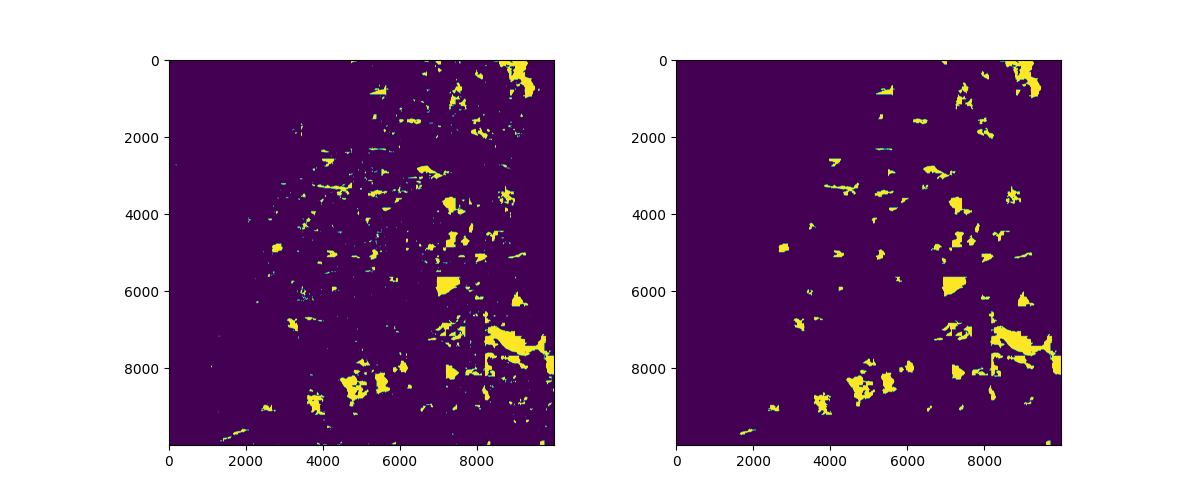

In [122]:
fig, axs = plt.subplots(1,2, figsize=(12,5))
axs[0].imshow(img_arr)
axs[1].imshow(img_arr_clustered)

##### Production

In [13]:
src_root = r"D:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\data\test_finetuning\with_multiple_versions\finetuning\preds"
src_originals = os.path.join(os.path.dirname(src_root), 'originals')
original_files = [os.path.splitext(x)[0] for x in os.listdir(src_originals)]
# print(original_files)
list_confs = [os.path.join(src_root,x) for x in os.listdir(src_root)]
for _, conf_path in tqdm(enumerate(list_confs), total=len(list_confs)):
    list_sample = [os.path.join(conf_path, 'masks', x) for x in os.listdir(os.path.join(conf_path, 'masks')) if 'img' in x]
    for src_img in list_sample:
        # print(src_img)
        with rasterio.open(src_img) as img:
            img_arr = np.moveaxis(img.read(), 0, 2)[...,0]
        img_arr[img_arr == 255] = 1
        minsize = int(os.path.basename(conf_path).split('minsize=')[1].split('_thpred')[0])
        # print(minsize)
        # break
        clusters_arr = clustering(
            img_arr=img_arr,
            eps=3, 
            min_samples=20, 
            min_cluster_size=minsize,
            )
        
        mask_clusters = clusters_arr == 0
        # img_arr_clustered = np.zeros(img_arr.shape, dtype=np.uint8)
        img_arr[mask_clusters] = 0

        tiff.imwrite(src_img, img_arr, compression="zstd", compressionargs={"level": 9})

        src_original = [os.path.join(src_originals, f"{x}.tif") for x in original_files if x in os.path.basename(src_img)][0]
        geo_transfert(src_original, src_img)
        create_transparent(src_img)
    #     break
    # break

  0%|          | 0/225 [00:00<?, ?it/s]d:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\.venv\lib\site-packages\rasterio\__init__.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
d:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\.venv\lib\site-packages\rasterio\__init__.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
d:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\.venv\lib\site-packages\rasterio\__init__.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
d:\GitHubProjects\Terranum_repo\LandSlides\segformerlandslides\.venv\lib\site-p